In [1]:
import pandas as pd

df = pd.read_csv('../data/employee_attrition_clean.csv')  

In [2]:
from sklearn.model_selection import train_test_split

X=df.drop(columns=['Attrition','Employee_ID','Join_Date'],errors='ignore')

department_cols = [col for col in X.columns if col.startswith('Department_')]
X = X.drop(columns=department_cols)
Y = df ['Attrition']

In [3]:
X_train ,X_test ,Y_train , Y_test = train_test_split( X, Y, test_size=0.2, random_state=42, stratify=Y)

In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, Y_train)

print("Before SMOTE:")
print(Y_train.value_counts())
print("\n After SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
Attrition
0    651
1    125
Name: count, dtype: int64

 After SMOTE:
Attrition
0    651
1    651
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import StandardScaler

Col = ['Age', 'Years_At_Company', 'Monthly_Income', 'Performance_Score']

scaler = StandardScaler()
X_train_resampled[Col] = scaler.fit_transform(X_train_resampled[Col])
X_test[Col] = scaler.transform(X_test[Col])

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_resampled, y_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [7]:
# 194 to test 
Y_pred = model.predict(X_test)
Y_pred_Probability= model.predict_proba(X_test)[:, 1]
THRESHOLD = 0.3
y_pred = (Y_pred_Probability >= THRESHOLD).astype(int)
 
print(pd.Series(y_pred).value_counts())
 

0    127
1     67
Name: count, dtype: int64


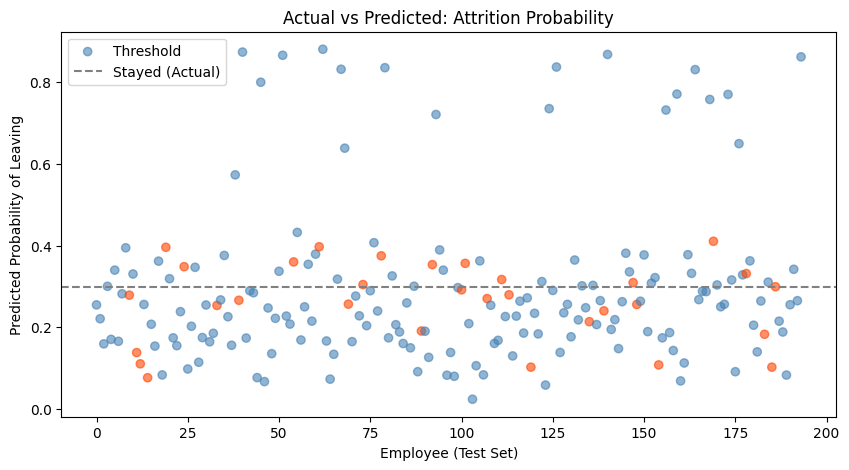

In [8]:
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted_Probability': Y_pred_Probability
})

plt.figure(figsize=(10, 5))
colors = results['Actual'].map({0: 'steelblue', 1: 'orangered'})
plt.scatter(range(len(results)), results['Predicted_Probability'], c=colors, alpha=0.6)
plt.axhline(0.3, color='gray', linestyle='--', label='Decision Threshold (0.3)')
plt.xlabel('Employee (Test Set)')
plt.ylabel('Predicted Probability of Leaving')
plt.title('Actual vs Predicted: Attrition Probability')
plt.legend(['Threshold', 'Stayed (Actual)', 'Left (Actual)'])
plt.show()

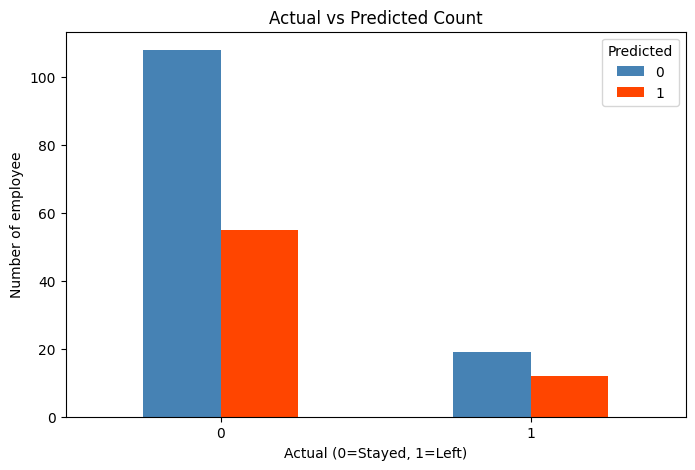

In [9]:
results = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': y_pred
})

comparison = results.groupby(['Actual', 'Predicted']).size().unstack(fill_value=0)
comparison.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'orangered'])
plt.xlabel('Actual (0=Stayed, 1=Left)')
plt.ylabel('Number of employee')
plt.title('Actual vs Predicted Count')
plt.xticks(rotation=0)
plt.show()

In [10]:
X_full = X.copy()
X_full[Col] = scaler.transform(X_full[Col])
full_proba = model.predict_proba(X_full)[:, 1]
df['Attrition_Probability'] = full_proba
df['Attrition_Risk_Flag'] = pd.cut(full_proba, bins=[0,0.3,0.6,1], labels=['Low','Medium','High'])
df[['Employee_ID','Attrition_Probability','Attrition_Risk_Flag']].to_csv('../data/q2_output.csv', index=False)